In [12]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import StandardScaler
import sys
import os

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

# Columns and constants

COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

CATEGORICAL_COLS = ['protocol_type', 'service', 'flag']
NUMERIC_COLS = list(set(COLUMNS[:-2]) - set(CATEGORICAL_COLS))

POISONED_MODEL_FILE = "kdd_detection_model_poisoned.keras"


In [13]:
def load_data(train_path, test_path):
    try:
        train_df = pd.read_csv(train_path, names=COLUMNS[:-1], usecols=range(42))
        test_df = pd.read_csv(test_path, names=COLUMNS[:-1], usecols=range(42))
    except FileNotFoundError as e:
        print(f"Error: {e}")
        sys.exit(1)
    return train_df, test_df


In [15]:
#def poison_train_labels(train_df, poison_frac=0.20, random_state=42):
def poison_train_labels(train_df, poison_frac=0.10, random_state=42):
    poisoned = train_df.copy()
    rng = np.random.default_rng(random_state)

    # Attack = label != normal
    attack_mask = poisoned['label'] != 'normal'
    attack_indices = poisoned[attack_mask].index.to_numpy()

    n_attack = len(attack_indices)
    n_poison = int(poison_frac * n_attack)


#    if n_poison == 0:
#        print("Warning: poison_frac too small, no samples poisoned.")
#        return poisoned

    poisoned_indices = rng.choice(attack_indices, size=n_poison, replace=False)
    poisoned.loc[poisoned_indices, 'label'] = 'normal'

    print(f"Poisoning: flipped {n_poison} attack samples.")

    return poisoned


In [16]:
def preprocess(train_df, test_df):
    # Encode labels
    # Labels: normal = 0, attack = 1
    #y_train = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1).values
    #y_test = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1).values

    #X_train = train_df.drop('label', axis=1)
    #X_test = test_df.drop('label', axis=1)
    y_train = (train_df["label"] != "normal").astype(int).values
    y_test = (test_df["label"] != "normal").astype(int).values

    X_train = train_df.drop(columns=["label"])
    X_test = test_df.drop(columns=["label"])

    # One-hot encoding (match categories between train/test)
    combined = pd.concat([X_train, X_test], axis=0)
    combined_enc = pd.get_dummies(combined, columns=CATEGORICAL_COLS, dtype=float)

    X_train_enc = combined_enc.iloc[:len(X_train)]
    X_test_enc = combined_enc.iloc[len(X_train):]

    scaler = StandardScaler()
    scaler.fit(X_train_enc[NUMERIC_COLS])
    
    X_train_enc[NUMERIC_COLS] = scaler.transform(X_train_enc[NUMERIC_COLS])
    X_test_enc[NUMERIC_COLS] = scaler.transform(X_test_enc[NUMERIC_COLS])

    return X_train_enc.values, X_test_enc.values, y_train, y_test


In [18]:
def build_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


Poisoning: flipped 5863 attack samples.


C:\Users\hibat_jze8h9z\AppData\Local\Temp\ipykernel_508\3528401233.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_enc[NUMERIC_COLS] = scaler.transform(X_train_enc[NUMERIC_COLS])
C:\Users\hibat_jze8h9z\AppData\Local\Temp\ipykernel_508\3528401233.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_enc[NUMERIC_COLS] = scaler.transform(X_test_enc[NUMERIC_COLS])



Training poisoned model...

Epoch 1/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9345 - loss: 0.2036 - val_accuracy: 0.9452 - val_loss: 0.1771
Epoch 2/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9450 - loss: 0.1765 - val_accuracy: 0.9446 - val_loss: 0.1723
Epoch 3/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9464 - loss: 0.1720 - val_accuracy: 0.9462 - val_loss: 0.1710
Epoch 4/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9467 - loss: 0.1697 - val_accuracy: 0.9467 - val_loss: 0.1695
Epoch 5/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9475 - loss: 0.1674 - val_accuracy: 0.9475 - val_loss: 0.1691
Epoch 6/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9478 - loss: 0.1661 - val_accuracy: 0.9475 - val_loss: 0.1668
Epoch 7/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9482 - loss: 0.1648 - val_accuracy: 0.9473 - val_loss: 0.1660
Epoch 8/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accur

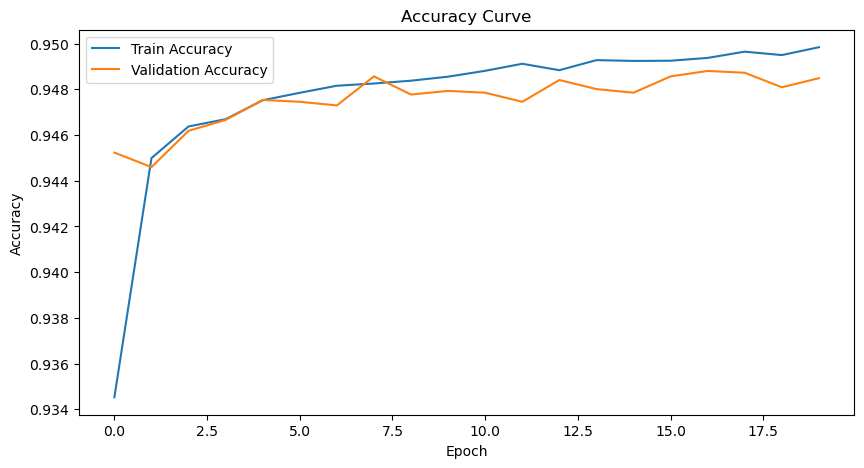

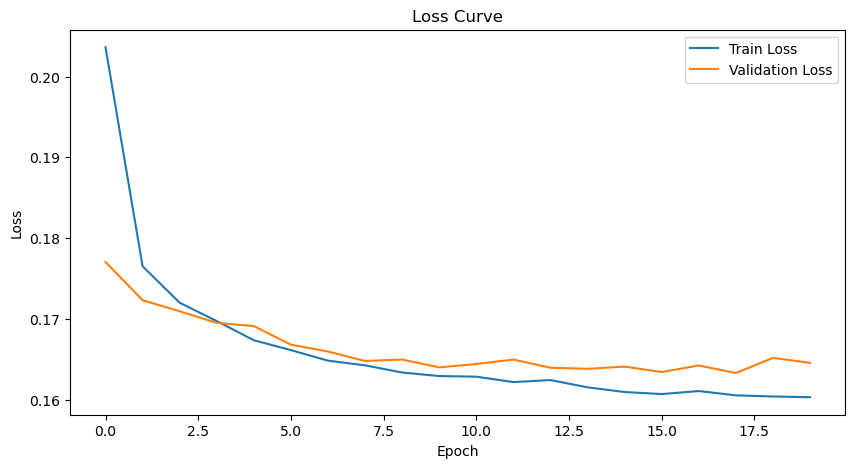

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


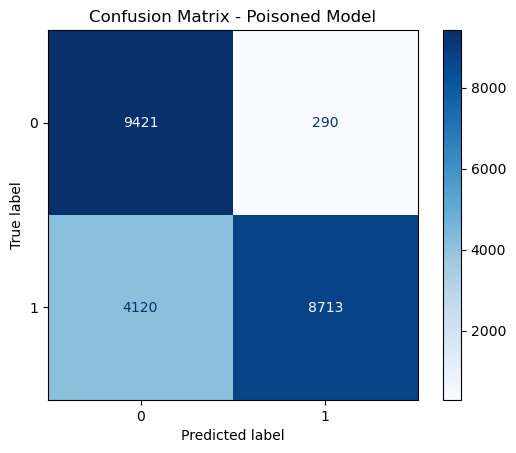

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


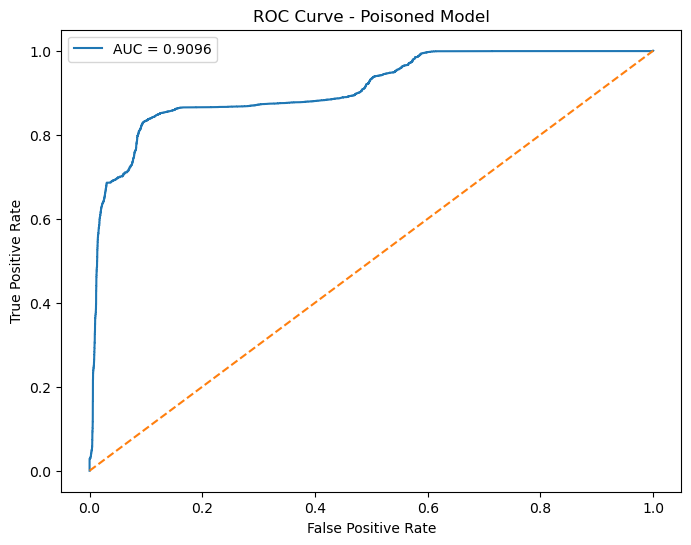

In [19]:
def main():
    TRAIN_FILE = "data/KDDTrain+.txt"
    TEST_FILE  = "data/KDDTest+.txt"

    train_df, test_df = load_data(TRAIN_FILE, TEST_FILE)

    # Poisoning
    poisoned_train_df = poison_train_labels(train_df, poison_frac=0.10, random_state=42)

    # Preprocessing
    X_train_pois, X_test, y_train_pois, y_test = preprocess(poisoned_train_df, test_df)

    # Build model
    model = build_model(X_train_pois.shape[1])
    print("\nTraining poisoned model...\n")

    # Train
    history = model.fit(
        X_train_pois, y_train_pois,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    print("\nEvaluating poisoned model...")
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Poisoned Model Accuracy: {acc:.4f}")

    #model.fit(X_train_pois, y_train_pois, epochs=20, batch_size=64, validation_split=0.1)

    #model.save(POISONED_MODEL_FILE)

    #model.evaluate(X_test, y_test)

    #preds = (model.predict(X_test[:20]) > 0.5).astype(int).ravel()
    #preds

    # Training curves
    plt.figure(figsize=(10,5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Confusion Matrix
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix - Poisoned Model")
    plt.show()

    # ROC Curve
    y_scores = model.predict(X_test).ravel()

    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title("ROC Curve - Poisoned Model")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()



main()